# Sieć dwuwarstwowa — Boston Housing (regresja)

**Cel:** przewidzieć medianę ceny domu w okolicy Bostonu (w tysiącach dolarów).

**Dataset:** 506 próbek, 13 cech numerycznych, target ciągły (regresja)

**Kluczowa różnica względem poprzednich zadań:**
- To jest **regresja**, nie klasyfikacja
- Wyjście sieci: jeden neuron **liniowy** (bez Sigmoid)
- Funkcja straty: **MSE** zamiast BCE
- Metryki: **MAE, RMSE, R²** zamiast accuracy/F1

**Architektura:** 13 → 32 → 1

## 1. Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.model_selection import train_test_split

np.random.seed(42)
torch.manual_seed(42)
plt.rcParams['figure.dpi'] = 100
os.makedirs('../plots', exist_ok=True)

print("Setup OK")

Setup OK


## 2. Wczytanie i eksploracja danych

**Cechy datasetu:**
| Cecha | Opis |
|-------|------|
| `crim` | wskaźnik przestępczości per capita |
| `zn` | procent gruntów mieszkalnych > 25000 sq.ft |
| `indus` | procent gruntów niehandlowych |
| `chas` | czy przy rzece Charles (0/1) |
| `nox` | stężenie tlenków azotu |
| `rm` | średnia liczba pokoi |
| `age` | procent budynków przed 1940 |
| `dis` | odległość od centrum zatrudnienia |
| `rad` | dostępność autostrad |
| `tax` | stawka podatku od nieruchomości |
| `ptratio` | stosunek uczniów do nauczycieli |
| `b` | wskaźnik demograficzny |
| `lstat` | procent ludności o niskim statusie |
| `medv` | **TARGET: mediana ceny domu (tys. $)** |

In [2]:
df = pd.read_csv('../data/boston_housing.csv')

print(f"Kształt: {df.shape}")
print(f"Kolumny: {df.columns.tolist()}")
print(f"\nBraki danych:")
print(df.isnull().sum())
print(f"\nStatystyki opisowe:")
df.describe().round(2)

Kształt: (506, 14)
Kolumny: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']

Braki danych:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Statystyki opisowe:


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


## 3. Eksploracja danych (EDA)

Dla regresji kluczowe pytania EDA:
- Jaki jest rozkład targetu (`medv`)? Czy jest skośny?
- Które cechy są najsilniej skorelowane z ceną?
- Czy są wartości odstające?

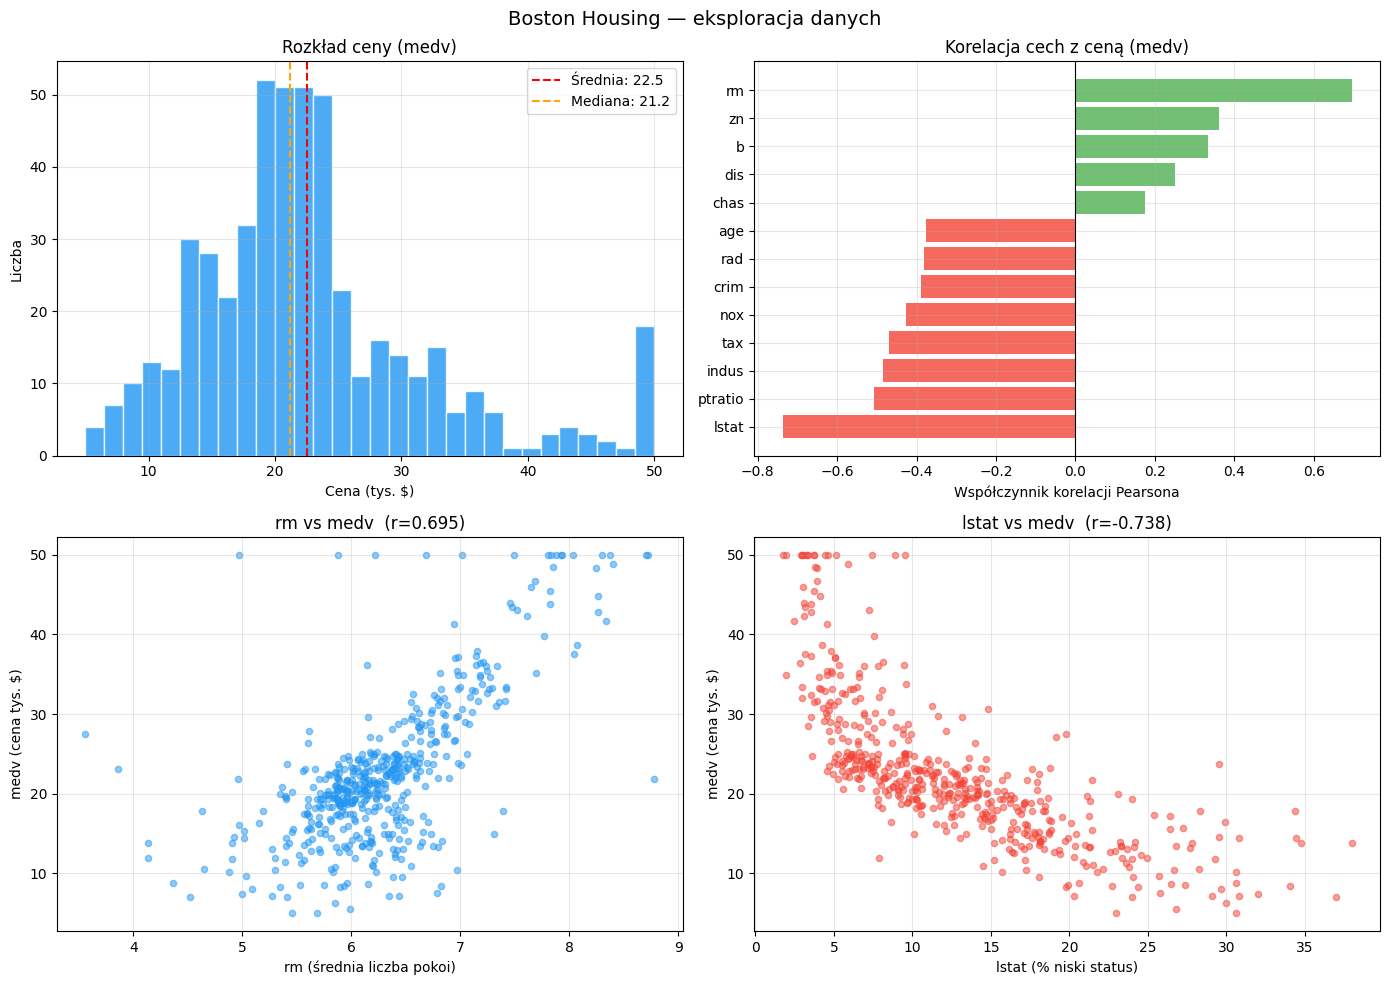

✓ Wykres zapisany


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Rozkład targetu ──
axes[0,0].hist(df['medv'], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
axes[0,0].axvline(df['medv'].mean(), color='red', linestyle='--',
                   label=f"Średnia: {df['medv'].mean():.1f}")
axes[0,0].axvline(df['medv'].median(), color='orange', linestyle='--',
                   label=f"Mediana: {df['medv'].median():.1f}")
axes[0,0].set_title('Rozkład ceny (medv)')
axes[0,0].set_xlabel('Cena (tys. $)')
axes[0,0].set_ylabel('Liczba')
axes[0,0].legend()
axes[0,0].grid(alpha=0.3)

# ── Korelacja cech z targetem ──
correlations = df.corr()['medv'].drop('medv').sort_values()
colors = ['#F44336' if c < 0 else '#4CAF50' for c in correlations]
axes[0,1].barh(correlations.index, correlations.values, color=colors, alpha=0.8)
axes[0,1].axvline(0, color='black', linewidth=0.8)
axes[0,1].set_title('Korelacja cech z ceną (medv)')
axes[0,1].set_xlabel('Współczynnik korelacji Pearsona')
axes[0,1].grid(alpha=0.3)

# ── rm vs medv (najsilniejsza korelacja pozytywna) ──
axes[1,0].scatter(df['rm'], df['medv'], alpha=0.5, color='#2196F3', s=20)
axes[1,0].set_xlabel('rm (średnia liczba pokoi)')
axes[1,0].set_ylabel('medv (cena tys. $)')
axes[1,0].set_title(f"rm vs medv  (r={df['rm'].corr(df['medv']):.3f})")
axes[1,0].grid(alpha=0.3)

# ── lstat vs medv (najsilniejsza korelacja negatywna) ──
axes[1,1].scatter(df['lstat'], df['medv'], alpha=0.5, color='#F44336', s=20)
axes[1,1].set_xlabel('lstat (% niski status)')
axes[1,1].set_ylabel('medv (cena tys. $)')
axes[1,1].set_title(f"lstat vs medv  (r={df['lstat'].corr(df['medv']):.3f})")
axes[1,1].grid(alpha=0.3)

plt.suptitle('Boston Housing — eksploracja danych', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boston_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

### 3.1

**Heatmapa korelacji**

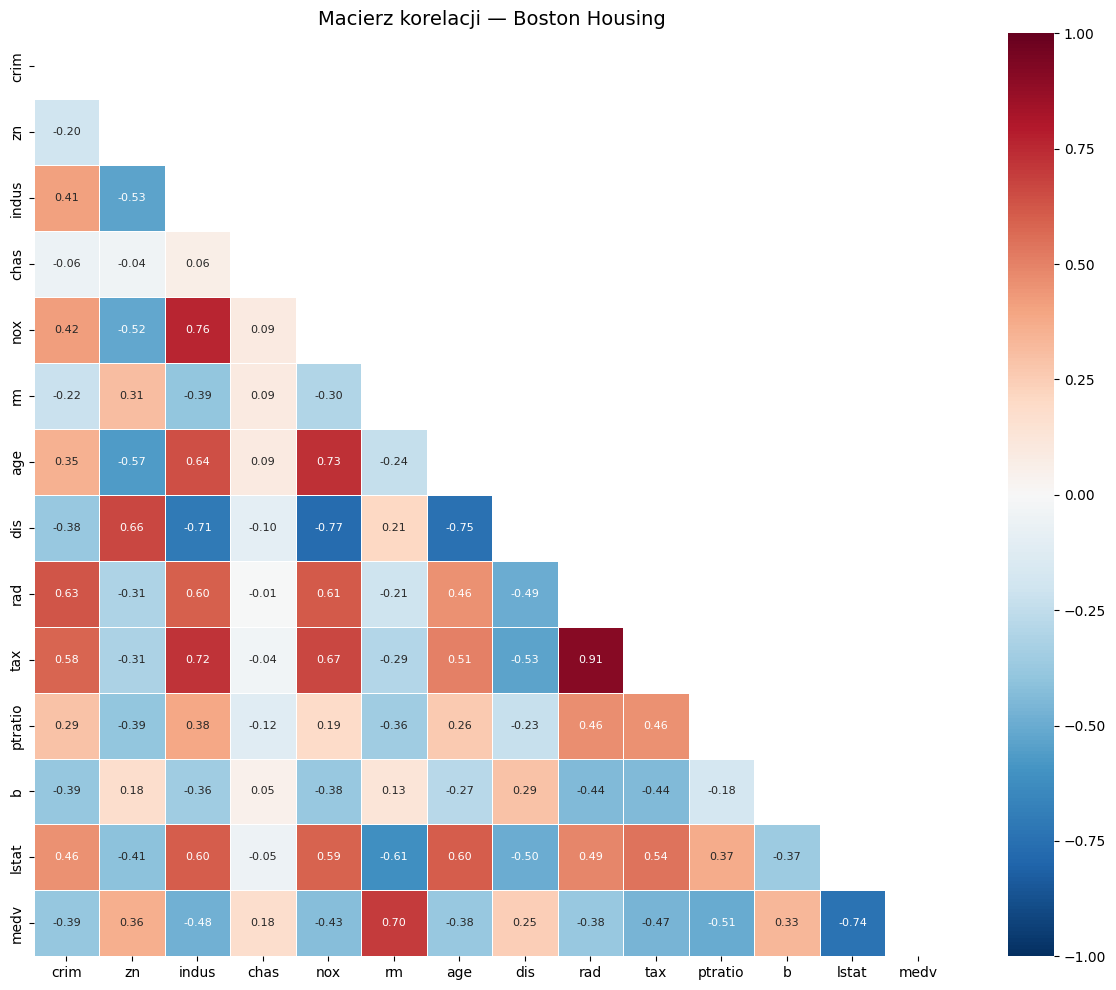

✓ Wykres zapisany


In [4]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            ax=ax, annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Macierz korelacji — Boston Housing', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boston_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 4. Podział i normalizacja

Standaryzujemy **wszystkie** cechy — w regresji to szczególnie ważne bo
cechy mają bardzo różne skale (np. `crim` ∈ [0, 89], `nox` ∈ [0.38, 0.87]).

**Uwaga:** normalizujemy też **target `medv`** — sieć łatwiej uczy się
przewidywać wartości w zakresie [-2, 2] niż [5, 50]. Przy ewaluacji
odwracamy normalizację żeby metryki były w oryginalnych jednostkach (tys. $).

In [5]:
feature_cols = [c for c in df.columns if c != 'medv']
X = df[feature_cols].values.astype(np.float32)
y = df['medv'].values.astype(np.float32)

print(f"Cechy ({len(feature_cols)}): {feature_cols}")
print(f"Target: medv — min={y.min():.1f}, max={y.max():.1f}, mean={y.mean():.1f}")

# ── Podział 80/20 ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain: {len(X_train)} | Test: {len(X_test)}")

# ── Standaryzacja cech ──
X_mean = X_train.mean(axis=0)
X_std  = X_train.std(axis=0) + 1e-8

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled  = (X_test  - X_mean) / X_std

# ── Standaryzacja targetu ──
y_mean = y_train.mean()
y_std  = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled  = (y_test  - y_mean) / y_std

print(f"\ny_train — mean={y_mean:.2f}, std={y_std:.2f}")
print(f"y_train_scaled — min={y_train_scaled.min():.2f}, max={y_train_scaled.max():.2f}")
print(f"\nNaN check — X: {np.isnan(X_train_scaled).sum()}, y: {np.isnan(y_train_scaled).sum()}")

Cechy (13): ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat']
Target: medv — min=5.0, max=50.0, mean=22.5

Train: 404 | Test: 102

y_train — mean=22.80, std=9.32
y_train_scaled — min=-1.91, max=2.92

NaN check — X: 0, y: 0


## 5. Trenowanie sieci

Architektura: **13 → 32 → 1**
- Wejście: 13 cech
- Warstwa ukryta: 32 neurony z aktywacją ReLU
- Wyjście: 1 neuron **liniowy** (brak aktywacji — regresja)
- Funkcja straty: MSE (Mean Squared Error)
- Optymalizator: SGD z mini-batchami (batch_size=32)

In [6]:
from utils.models import TwoLayerNetwork

model_boston = TwoLayerNetwork(
    n_input=13,
    n_hidden=32,
    n_output=1,
    lr=0.01,
    mode='regression'
)

history = model_boston.train_network(
    X_train_scaled, y_train_scaled,
    epochs=2000,
    batch_size=32,
    verbose=True
)

Epoch     0/2000 | Loss: 1.164696
Epoch   200/2000 | Loss: 0.093941
Epoch   400/2000 | Loss: 0.072372
Epoch   600/2000 | Loss: 0.061777
Epoch   800/2000 | Loss: 0.055972
Epoch  1000/2000 | Loss: 0.051516
Epoch  1200/2000 | Loss: 0.047962
Epoch  1400/2000 | Loss: 0.042931
Epoch  1600/2000 | Loss: 0.041669
Epoch  1800/2000 | Loss: 0.038215


## 6. Wykresy uczenia

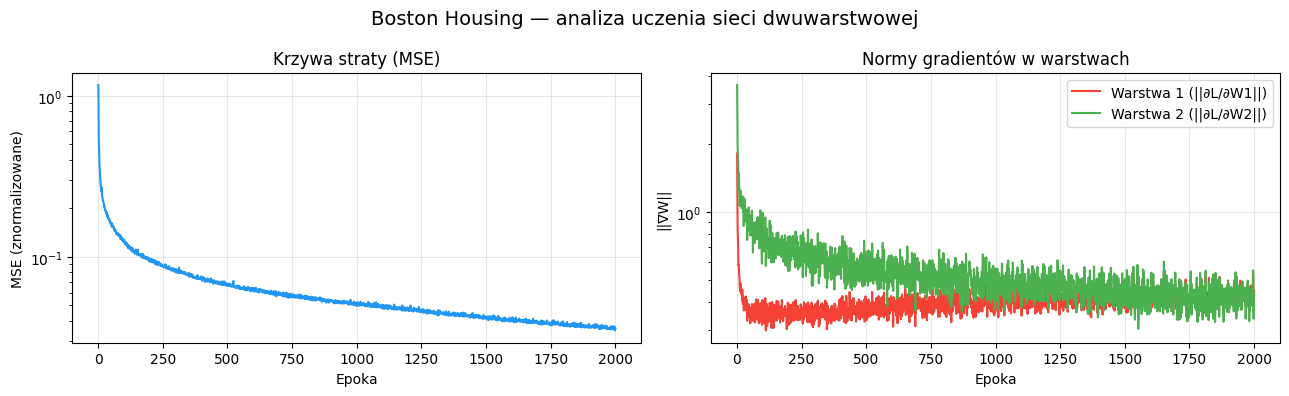

✓ Wykres zapisany


In [7]:
epochs_range = range(1, len(history['loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Loss ──
axes[0].plot(epochs_range, history['loss'], color='#2196F3', linewidth=1.5)
axes[0].set_title('Krzywa straty (MSE)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE (znormalizowane)')
axes[0].set_yscale('log')
axes[0].grid(alpha=0.3)

# ── Gradienty warstw ──
axes[1].plot(epochs_range, history['grad_norm_W1'],
             label='Warstwa 1 (||∂L/∂W1||)', color='#F44336', linewidth=1.5)
axes[1].plot(epochs_range, history['grad_norm_W2'],
             label='Warstwa 2 (||∂L/∂W2||)', color='#4CAF50', linewidth=1.5)
axes[1].set_title('Normy gradientów w warstwach')
axes[1].set_xlabel('Epoka')
axes[1].set_ylabel('||∇W||')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Boston Housing — analiza uczenia sieci dwuwarstwowej', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boston_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 7 Drzewo decyzyjne — punkt odniesienia

Przed trenowaniem sieci neuronowej budujemy drzewo decyzyjne dla tego
samego problemu. Służy jako **baseline** — jeśli sieć neuronowa nie
bije drzewa, architektura lub preprocessing wymagają poprawy.

Drzewo decyzyjne dla regresji używa **wariancji (MSE)** zamiast Gini
jako kryterium podziału — wybiera próg minimalizujący łączną wariancję
lewego i prawego poddrzewa.

In [8]:
from utils.models import DecisionTreeRegressor

tree_reg = DecisionTreeRegressor(max_depth=5, min_samples_split=10)
tree_reg.fit(X_train_scaled, y_train_scaled)  # trenuj na znormalizowanych

# Predykcje — odwróć normalizację
y_pred_tree_scaled = tree_reg.predict(X_test_scaled)
y_pred_tree = y_pred_tree_scaled * y_std + y_mean  # powrót do tys. $

# Metryki w oryginalnych jednostkach
tree_mae  = np.mean(np.abs(y_pred_tree - y_test))
tree_rmse = np.sqrt(np.mean((y_pred_tree - y_test)**2))
ss_res    = np.sum((y_test - y_pred_tree)**2)
ss_tot    = np.sum((y_test - y_test.mean())**2)
tree_r2   = 1 - ss_res / ss_tot

print("── Drzewo decyzyjne — wyniki ──")
print(f"  MAE:  {tree_mae:.2f} tys. $")
print(f"  RMSE: {tree_rmse:.2f} tys. $")
print(f"  R²:   {tree_r2:.4f}")

── Drzewo decyzyjne — wyniki ──
  MAE:  2.76 tys. $
  RMSE: 4.29 tys. $
  R²:   0.7492


### 7.1 Porównanie drzewa decyzyjnego z siecią neuronową

               Drzewo decyzyjne  Sieć neuronowa
MAE (tys. $)             2.7568          2.2720
RMSE (tys. $)            4.2883          3.4869
R²                       0.7492          0.8342


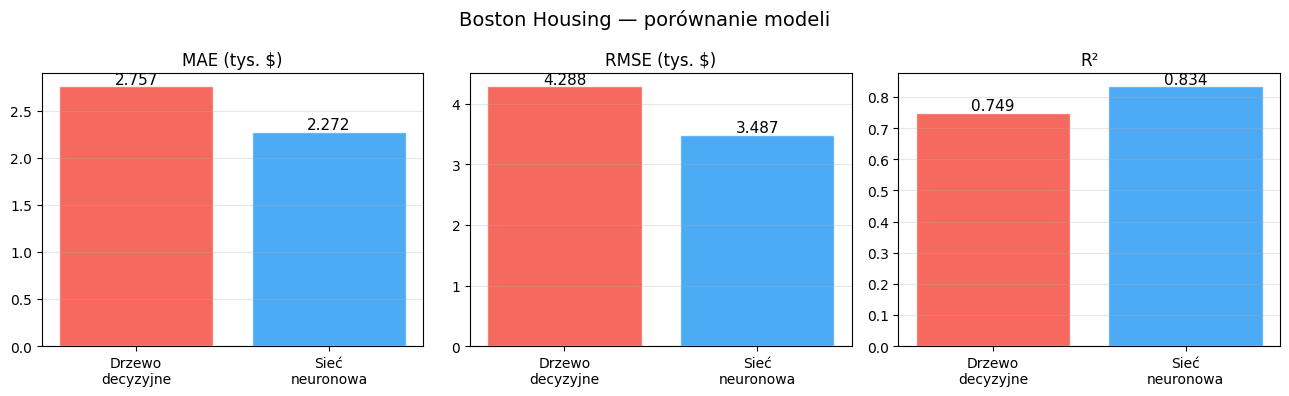

✓ Wykres zapisany


In [10]:
# ── Porównanie: Drzewo decyzyjne vs Sieć neuronowa ──
y_pred_net = model_boston.predict(X_test_scaled) * y_std + y_mean

net_mae  = np.mean(np.abs(y_pred_net - y_test))
net_rmse = np.sqrt(np.mean((y_pred_net - y_test)**2))
ss_res   = np.sum((y_test - y_pred_net)**2)
ss_tot   = np.sum((y_test - y_test.mean())**2)
net_r2   = 1 - ss_res / ss_tot

# ── Tabela porównawcza ──
import pandas as pd
comparison = pd.DataFrame({
    'Drzewo decyzyjne': {'MAE (tys. $)': tree_mae, 'RMSE (tys. $)': tree_rmse, 'R²': tree_r2},
    'Sieć neuronowa':   {'MAE (tys. $)': net_mae,  'RMSE (tys. $)': net_rmse,  'R²': net_r2}
}).round(4)
print(comparison)

# ── Wykres porównawczy ──
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics   = ['MAE (tys. $)', 'RMSE (tys. $)', 'R²']
tree_vals = [tree_mae, tree_rmse, tree_r2]
net_vals  = [net_mae,  net_rmse,  net_r2]

for i, (metric, tv, nv) in enumerate(zip(metrics, tree_vals, net_vals)):
    bars = axes[i].bar(['Drzewo\ndecyzyjne', 'Sieć\nneuronowa'],
                        [tv, nv], color=['#F44336', '#2196F3'], alpha=0.8,
                        edgecolor='white')
    axes[i].set_title(metric)
    axes[i].grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, [tv, nv]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01 * max(tv, nv),
                     f'{val:.3f}', ha='center', fontsize=11)

plt.suptitle('Boston Housing — porównanie modeli', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boston_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 8. Ewaluacja na zbiorze testowym

Metryki dla regresji (wszystkie w oryginalnych jednostkach — tys. $):
- **MAE** (Mean Absolute Error) — średni błąd bezwzględny: o ile średnio mylimy się w cenie
- **RMSE** (Root Mean Squared Error) — silniej karze duże błędy
- **R²** (współczynnik determinacji) — ile wariancji targetu wyjaśnia model
  - R²=1.0 → idealne dopasowanie
  - R²=0.0 → model nie lepszy niż przewidywanie średniej
  - R²<0.0 → model gorszy niż przewidywanie średniej

── Metryki na zbiorze testowym ──
  MAE:  2.27 tys. $
  RMSE: 3.49 tys. $
  R²:   0.8342


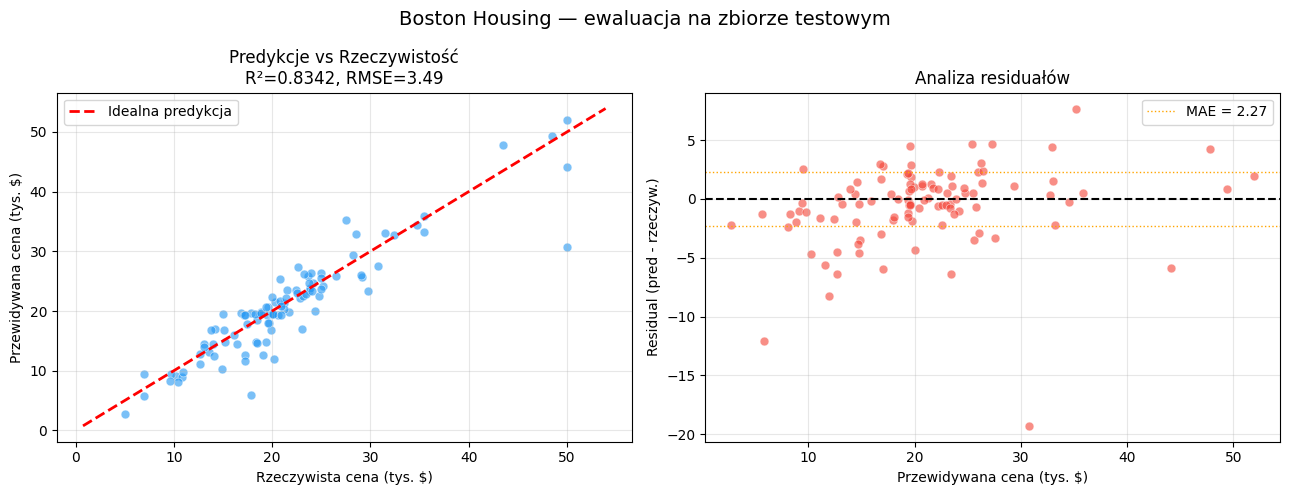

✓ Wykres zapisany


In [9]:
# ── Predykcje (odwróć normalizację targetu) ──
y_pred_scaled = model_boston.predict(X_test_scaled)
y_pred = y_pred_scaled * y_std + y_mean   # powrót do oryginalnych jednostek

# ── Metryki ──
mae  = np.mean(np.abs(y_pred - y_test))
rmse = np.sqrt(np.mean((y_pred - y_test)**2))
ss_res = np.sum((y_test - y_pred)**2)
ss_tot = np.sum((y_test - y_test.mean())**2)
r2 = 1 - ss_res / ss_tot

print("── Metryki na zbiorze testowym ──")
print(f"  MAE:  {mae:.2f} tys. $")
print(f"  RMSE: {rmse:.2f} tys. $")
print(f"  R²:   {r2:.4f}")

# ── Wykres: predykcje vs rzeczywistość ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter: y_pred vs y_true
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#2196F3', s=40, edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), y_pred.min()) - 2
max_val = max(y_test.max(), y_pred.max()) + 2
axes[0].plot([min_val, max_val], [min_val, max_val],
             'r--', linewidth=2, label='Idealna predykcja')
axes[0].set_xlabel('Rzeczywista cena (tys. $)')
axes[0].set_ylabel('Przewidywana cena (tys. $)')
axes[0].set_title(f'Predykcje vs Rzeczywistość\nR²={r2:.4f}, RMSE={rmse:.2f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residuals: błędy predykcji
residuals = y_pred - y_test
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#F44336', s=40,
                edgecolors='white', linewidth=0.5)
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].axhline(mae, color='orange', linewidth=1, linestyle=':',
                label=f'MAE = {mae:.2f}')
axes[1].axhline(-mae, color='orange', linewidth=1, linestyle=':')
axes[1].set_xlabel('Przewidywana cena (tys. $)')
axes[1].set_ylabel('Residual (pred - rzeczyw.)')
axes[1].set_title('Analiza residuałów')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Boston Housing — ewaluacja na zbiorze testowym', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/boston_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Wykres zapisany")

## 9. Wnioski

### Eksploracja danych
Dataset jest kompletny — brak braków danych. Target `medv` ma rozkład
prawostronnie skośny (średnia 22.5 > mediana 21.2), z koncentracją wartości
w przedziale 15-25 tys. $ i widocznym skupiskiem na poziomie 50 tys. $
(prawdopodobnie wartości ucięte — górny limit zbioru).

Najsilniejsze korelacje z ceną:
- `lstat` (r=-0.738) — im więcej ludności o niskim statusie, tym niższa cena
- `rm` (r=0.695) — więcej pokoi → wyższa cena
- `ptratio` (r=-0.508) — gorszy stosunek uczniów/nauczyciel → niższa cena

Warta uwagi silna multikolinearność między cechami: `tax` i `rad` (r=0.91),
`nox` i `indus` (r=0.76), `nox` i `age` (r=0.73) — cechy opisują te same
aspekty okolicy z różnych stron.

### Przebieg uczenia
Sieć uczyła się bardzo efektywnie — MSE spadł z 1.165 do ~0.038 (skala
znormalizowana), czyli prawie 30-krotna redukcja błędu. Największy postęp
nastąpił w pierwszych 200 epokach, po czym krzywa spłaszcza się —
typowy kształt logarytmiczny konwergencji SGD.

Normy gradientów (wykres 2) pokazują charakterystyczny wzorzec:
- **Warstwa 2** (zielona, bliżej wyjścia) startuje z bardzo wysokim gradientem
  (~10¹) i szybko opada — to warstwa która bezpośrednio widzi błąd predykcji
- **Warstwa 1** (czerwona, bliżej wejścia) ma konsekwentnie mniejszy gradient
  przez cały trening — sygnał błędu słabnie przechodząc przez W2 (zanikający
  gradient). Mimo to obie warstwy po epoce ~200 stabilizują się na podobnym
  poziomie (~0.1), co świadczy o zdrowym przepływie gradientu.

### Wyniki na zbiorze testowym

| Metryka | Wartość | Interpretacja |
|---------|---------|---------------|
| MAE | 2.27 tys. $ | model myli się średnio o **2270 $** |
| RMSE | 3.49 tys. $ | duże błędy są karane — kilka dużych odchyleń |
| R² | 0.8342 | model wyjaśnia **83.4%** wariancji cen |

### Analiza residuałów
Wykres predykcje vs rzeczywistość pokazuje dobrą zgodność — punkty układają
się blisko czerwonej linii idealnej predykcji dla cen 10-35 tys. $.

Widoczne są dwa systemy błędów:
1. **Domy tanie** (medv < 10 tys. $) — model zawyża ceny, prawdopodobnie
   dlatego że takich próbek jest mało w datasecie
2. **Domy drogie** (medv = 50 tys. $) — skupisko punktów przy wartości 50
   to ucięte dane (górny limit), model nie może ich poprawnie przewidzieć
   bo nie wie że cena była wyższa

Residuały są w większości losowo rozrzucone wokół 0 w zakresie ±MAE=2.27
co potwierdza że model nie ma systematycznych błędów dla typowych wartości.

### Porównanie z drzewem decyzyjnym

| Metryka | Drzewo decyzyjne | Sieć neuronowa | Poprawa |
|---------|-----------------|----------------|---------|
| MAE (tys. $) | 2.76 | **2.27** | -17.7% |
| RMSE (tys. $) | 4.29 | **3.49** | -18.6% |
| R² | 0.7492 | **0.8342** | +11.3% |

Sieć neuronowa przewyższa drzewo decyzyjne we wszystkich metrykach.
Drzewo decyzyjne (max_depth=5) osiągnęło R²=0.749 — wyjaśnia 74.9%
wariancji cen, popełniając średni błąd 2.76 tys. $. Ograniczenie głębokości
do 5 poziomów zapobiega overfittingowi kosztem dokładności — głębsze drzewo
zapamiętałoby dane treningowe bez dobrej generalizacji.

Sieć neuronowa (13→32→1, 2000 epok) osiągnęła R²=0.834 i MAE=2.27 tys. $,
co oznacza poprawę o ~18% względem drzewa. Wynika to ze zdolności sieci do
modelowania nieliniowych interakcji między cechami — np. zależność ceny od
liczby pokoi (`rm`) jest nieliniowa i sieć lepiej ją aproksymuje niż
sekwencja progów w drzewie.

Oba modele mają trudności z domami o cenie 50 tys. $ (wartości ucięte
w datasecie) — widoczne jako skupisko punktów odstających na wykresie
residuałów.